# 03 EDA and Feature Review

This notebook reviews the engineered customer feature table before clustering. The goal is to understand the feature groups, identify useful modeling candidates, and separate them from fields that are better used only for profiling or validation.

No clustering model is trained in this notebook, and no final clustering output file is created.


## Purpose of this notebook

The data audit and preprocessing notebooks already checked the raw data and built a clean customer-level feature table. This phase asks a different question: which engineered features are useful for clustering, and which ones should only help us explain the clusters afterwards?

The notebook keeps the review simple and defense-friendly. It uses validation checks, compact summary tables, and a few optional plots instead of a large exploratory analysis.


## Setup and data loading

This section locates the project root, imports the existing project helpers, and loads the raw datasets. The fixed reference date makes age and tenure calculations reproducible.


In [16]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOTS_AVAILABLE = True
except ImportError:
    plt = None
    PLOTS_AVAILABLE = False

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)


def has_raw_datasets(candidate):
    root_layout = (candidate / "customer_info.csv").exists() and (candidate / "customer_basket.csv").exists()
    project_files_layout = (candidate / "Project files" / "customer_info.csv").exists() and (candidate / "Project files" / "customer_basket.csv").exists()
    return root_layout or project_files_layout


def find_project_root(start):
    for candidate in [start, *start.parents]:
        if has_raw_datasets(candidate):
            return candidate
    raise FileNotFoundError("Could not locate raw datasets at the repository root or in Project files/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REFERENCE_DATE = pd.Timestamp("2026-05-30")
print(f"Project root: {PROJECT_ROOT}")
print(f"Reference date for age and tenure: {REFERENCE_DATE.date()}")
print(f"Matplotlib available for optional plots: {PLOTS_AVAILABLE}")


Project root: C:\Users\pedro\Desktop\ML-II-projeto-final
Reference date for age and tenure: 2026-05-30
Matplotlib available for optional plots: True


In [17]:
from src.data_loading import load_datasets
from src.features import build_customer_feature_table


In [18]:
customer_info, customer_basket = load_datasets(PROJECT_ROOT)

print(f"customer_info rows: {len(customer_info):,}")
print(f"unique customers in customer_info: {customer_info['customer_id'].nunique():,}")
print(f"customer_basket rows: {len(customer_basket):,}")


customer_info rows: 33,038
unique customers in customer_info: 33,038
customer_basket rows: 100,000


## Build and validate feature table

The feature table is built with the existing project workflow. The validation checks confirm that the table is still complete, clean, and safe to review before clustering.


In [19]:
feature_table, metadata = build_customer_feature_table(
    customer_info,
    customer_basket,
    reference_date=REFERENCE_DATE,
)

print(f"feature table shape: {feature_table.shape}")
print(f"output customer count: {metadata['output_customer_count']:,}")
print(f"basket parse errors: {metadata['basket_parse_errors']}")
print(f"customers without sampled baskets: {metadata['customers_without_baskets']:,}")


feature table shape: (33038, 77)
output customer count: 33,038
basket parse errors: 0
customers without sampled baskets: 4,911


In [20]:
degree_columns = ["degree_bsc", "degree_msc", "degree_phd", "degree_unknown"]
outputs_dir = PROJECT_ROOT / "outputs"
final_output_files = []

if outputs_dir.exists():
    for path in outputs_dir.iterdir():
        name = path.name.lower()
        looks_like_final_cluster_output = path.suffix.lower() == ".csv" and (
            "cluster" in name or "segment" in name
        )
        if path.is_file() and looks_like_final_cluster_output:
            final_output_files.append(path.name)

validation_results = pd.DataFrame(
    [
        {"check": "expected customer count", "value": metadata["output_customer_count"], "passes": metadata["output_customer_count"] == 33038},
        {"check": "expected feature table shape", "value": str(feature_table.shape), "passes": feature_table.shape == (33038, 77)},
        {"check": "customer_id is unique", "value": feature_table["customer_id"].is_unique, "passes": feature_table["customer_id"].is_unique},
        {"check": "missing values", "value": int(feature_table.isna().sum().sum()), "passes": int(feature_table.isna().sum().sum()) == 0},
        {"check": "customer_name excluded", "value": "customer_name" in feature_table.columns, "passes": "customer_name" not in feature_table.columns},
        {"check": "degree columns present", "value": all(column in feature_table.columns for column in degree_columns), "passes": all(column in feature_table.columns for column in degree_columns)},
        {"check": "degree flags sum to one", "value": bool((feature_table[degree_columns].sum(axis=1) == 1).all()), "passes": bool((feature_table[degree_columns].sum(axis=1) == 1).all())},
        {"check": "no final clustering csv outputs", "value": final_output_files, "passes": len(final_output_files) == 0},
    ]
)

display(validation_results)
assert validation_results["passes"].all()
print("Validation passed. No clustering was performed and no final clustering output file was found.")


,check,value,passes
0,expected customer count,33038,True
1,expected feature table shape,"(33038, 77)",True
2,customer_id is unique,True,True
3,missing values,0,True
4,customer_name excluded,False,True
5,degree columns present,True,True
6,degree flags sum to one,True,True
7,no final clustering csv outputs,[],True


Validation passed. No clustering was performed and no final clustering output file was found.


## Feature group inventory

Before selecting modeling features, it helps to group columns by meaning. This inventory shows what exists in the feature table and gives examples from each group.


In [21]:
spend_amount_columns = [column for column in feature_table.columns if column.startswith("lifetime_spend_")]
spend_share_columns = [column for column in feature_table.columns if column.startswith("spend_share_")]
missingness_columns = [column for column in feature_table.columns if column.endswith("_was_missing")]
quality_flag_columns = [
    column for column in feature_table.columns
    if "suspicious" in column or "missing_or_invalid" in column or column.endswith("_missing")
]

feature_groups = {
    "row key": ["customer_id"],
    "demographic": ["customer_age", "gender_female", "gender_male", "gender_unknown"],
    "degree": degree_columns,
    "household": ["kids_home", "teens_home", "total_children_home", "has_kids_home", "has_teens_home", "has_children_home"],
    "location": ["latitude", "longitude"],
    "tenure": ["customer_tenure_years"],
    "loyalty_complaints_promotion": ["has_loyalty_card", "loyalty_card_missing", "number_complaints", "promotion_pct_clean", "promotion_pct_suspicious"],
    "spend_amounts": ["total_lifetime_spend", *spend_amount_columns],
    "spend_shares": spend_share_columns,
    "basket_behavior": ["basket_count", "avg_basket_size", "median_basket_size", "max_basket_size", "total_basket_items", "unique_basket_products", "has_sampled_basket"],
    "data_quality_missingness": sorted(set(missingness_columns + quality_flag_columns)),
}

inventory_rows = []
for group, columns in feature_groups.items():
    existing_columns = [column for column in columns if column in feature_table.columns]
    inventory_rows.append(
        {
            "feature_group": group,
            "column_count": len(existing_columns),
            "example_features": ", ".join(existing_columns[:6]),
        }
    )

feature_inventory = pd.DataFrame(inventory_rows)
display(feature_inventory)


,feature_group,column_count,example_features
0,row key,1,customer_id
1,demographic,4,"customer_age, gender_female, gender_male, gend..."
2,degree,4,"degree_bsc, degree_msc, degree_phd, degree_unk..."
3,household,6,"kids_home, teens_home, total_children_home, ha..."
4,location,2,"latitude, longitude"
5,tenure,1,customer_tenure_years
6,loyalty_complaints_promotion,5,"has_loyalty_card, loyalty_card_missing, number..."
7,spend_amounts,19,"total_lifetime_spend, lifetime_spend_groceries..."
8,spend_shares,10,"spend_share_groceries, spend_share_electronics..."
9,basket_behavior,7,"basket_count, avg_basket_size, median_basket_s..."


## Demographic and household EDA

These features describe who the customers are and basic household structure. They can help with interpretation, but demographic variables should be reviewed carefully before becoming modeling inputs.


In [22]:
demographic_columns = ["customer_age", "kids_home", "teens_home", "total_children_home"]
demographic_summary = feature_table[demographic_columns].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

gender_distribution = feature_table[["gender_female", "gender_male", "gender_unknown"]].sum().rename("customer_count").to_frame()
gender_distribution["percent"] = (gender_distribution["customer_count"] / len(feature_table) * 100).round(2)

household_distribution = feature_table[["has_kids_home", "has_teens_home", "has_children_home"]].sum().rename("customer_count").to_frame()
household_distribution["percent"] = (household_distribution["customer_count"] / len(feature_table) * 100).round(2)

print("Demographic and household numeric summary")
display(demographic_summary)
print("Gender indicator distribution")
display(gender_distribution)
print("Household indicator distribution")
display(household_distribution)


Demographic and household numeric summary


,mean,std,min,25%,50%,75%,max
customer_age,55.02,18.02,24.41,39.25,54.9,70.66,86.4
kids_home,1.11,1.14,0.00,0.00,1.0,1.00,8.0
teens_home,0.90,0.96,0.00,0.00,1.0,1.00,6.0
total_children_home,2.01,1.77,0.00,1.00,2.0,2.00,14.0


Gender indicator distribution


,customer_count,percent
gender_female,16577,50.18
gender_male,16461,49.82
gender_unknown,0,0.00


Household indicator distribution


,customer_count,percent
has_kids_home,23835,72.14
has_teens_home,21581,65.32
has_children_home,28465,86.16


## Spend behavior EDA

Spend features are strong candidates for clustering because they describe customer behavior. Raw spend amounts may be skewed, so they should usually be scaled and possibly log-transformed before distance-based clustering.


Spend amount summary


,mean,std,min,25%,50%,75%,max
total_lifetime_spend,23706.24,13360.28,2174.0,14482.00,20269.0,29163.0,116366.0
lifetime_spend_groceries,16306.23,11985.90,0.0,8647.00,13002.5,20807.0,104670.0
lifetime_spend_electronics,2737.21,3423.26,0.0,592.00,1470.0,3674.0,35299.0
lifetime_spend_vegetables,722.10,649.04,0.0,228.25,471.0,1053.0,3337.0
lifetime_spend_nonalcohol_drinks,464.35,275.77,0.0,241.00,421.0,640.0,2180.0
lifetime_spend_alcohol_drinks,620.75,515.34,0.0,203.00,483.0,886.0,3704.0
lifetime_spend_meat,723.83,478.17,0.0,355.00,729.0,1003.0,3052.0
lifetime_spend_fish,605.85,489.84,0.0,180.00,511.0,907.0,3172.0
lifetime_spend_hygiene,819.00,605.42,0.0,365.00,686.0,1114.0,3482.0
lifetime_spend_videogames,370.88,456.64,0.0,126.00,223.0,370.0,3936.0


Average spend share by category


,mean_share
spend_share_groceries,0.648
spend_share_electronics,0.116
spend_share_hygiene,0.043
spend_share_vegetables,0.042
spend_share_meat,0.036
spend_share_alcohol_drinks,0.029
spend_share_fish,0.028
spend_share_nonalcohol_drinks,0.023
spend_share_petfood,0.018
spend_share_videogames,0.018


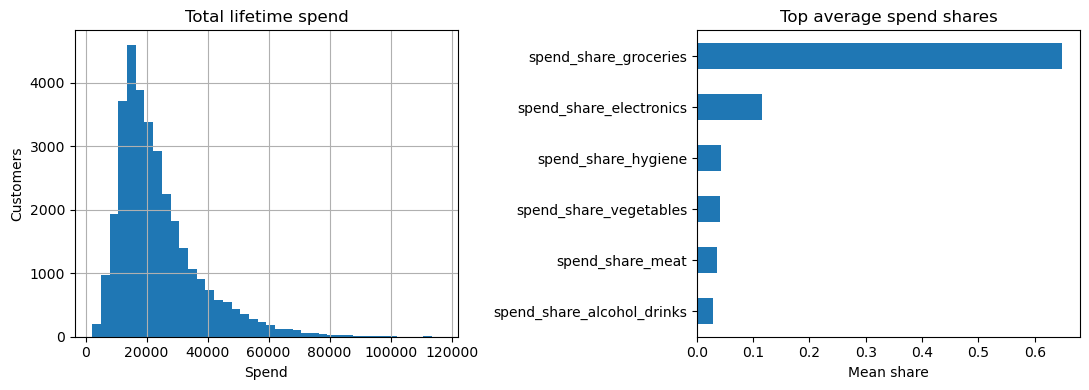

In [23]:
spend_summary_columns = ["total_lifetime_spend", *spend_amount_columns]
spend_summary = feature_table[spend_summary_columns].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

average_spend_shares = feature_table[spend_share_columns].mean().sort_values(ascending=False).rename("mean_share").to_frame()
average_spend_shares["mean_share"] = average_spend_shares["mean_share"].round(3)

print("Spend amount summary")
display(spend_summary)
print("Average spend share by category")
display(average_spend_shares)

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    feature_table["total_lifetime_spend"].hist(bins=40, ax=axes[0])
    axes[0].set_title("Total lifetime spend")
    axes[0].set_xlabel("Spend")
    axes[0].set_ylabel("Customers")

    average_spend_shares.head(6).sort_values("mean_share").plot(kind="barh", ax=axes[1], legend=False)
    axes[1].set_title("Top average spend shares")
    axes[1].set_xlabel("Mean share")
    plt.tight_layout()
    plt.show()
else:
    print("Optional spend plots skipped because matplotlib is not available in this environment.")


## Basket behavior EDA

Basket features are useful because they describe sampled transaction behavior. The `has_sampled_basket` flag is important because customers without sampled baskets receive zero basket values.


Basket feature summary


,mean,std,min,25%,50%,75%,max
basket_count,3.03,2.85,0.0,1.00,2.0,4.00,33.0
avg_basket_size,7.97,4.12,0.0,6.23,9.0,10.67,18.0
median_basket_size,7.97,4.25,0.0,6.00,9.0,11.00,18.0
max_basket_size,10.32,5.37,0.0,7.00,12.0,14.00,18.0
total_basket_items,28.45,27.94,0.0,9.00,21.0,41.00,324.0
unique_basket_products,23.76,20.26,0.0,9.00,20.0,35.00,145.0


Sampled basket coverage


,has_sampled_basket,customer_count,percent
0,1,28127,85.14
1,0,4911,14.86


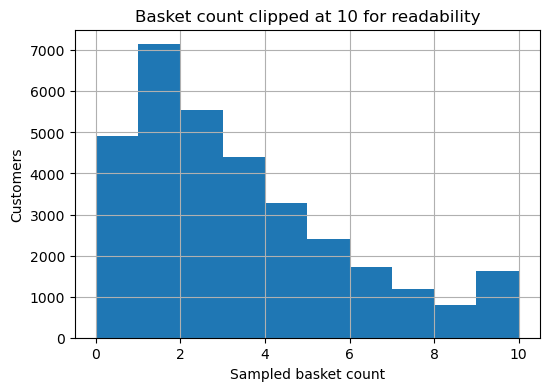

In [24]:
basket_columns = ["basket_count", "avg_basket_size", "median_basket_size", "max_basket_size", "total_basket_items", "unique_basket_products"]
basket_summary = feature_table[basket_columns].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

basket_presence = feature_table["has_sampled_basket"].value_counts().rename_axis("has_sampled_basket").reset_index(name="customer_count")
basket_presence["percent"] = (basket_presence["customer_count"] / len(feature_table) * 100).round(2)

print("Basket feature summary")
display(basket_summary)
print("Sampled basket coverage")
display(basket_presence)

if PLOTS_AVAILABLE:
    feature_table["basket_count"].clip(upper=10).hist(bins=10, figsize=(6, 4))
    plt.title("Basket count clipped at 10 for readability")
    plt.xlabel("Sampled basket count")
    plt.ylabel("Customers")
    plt.show()
else:
    print("Optional basket plot skipped because matplotlib is not available in this environment.")


## Loyalty, complaints, and promotion EDA

These features describe engagement and possible dissatisfaction. They can be useful for profiling clusters and may also be modeling candidates if the project wants segments that reflect loyalty and promotion behavior.


In [25]:
loyalty_columns = ["has_loyalty_card", "loyalty_card_missing", "number_complaints", "promotion_pct_clean", "promotion_pct_suspicious", "promotion_pct_missing"]
loyalty_summary = feature_table[loyalty_columns].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(3)

loyalty_distribution = feature_table[["has_loyalty_card", "loyalty_card_missing", "promotion_pct_suspicious", "promotion_pct_missing"]].sum().rename("customer_count").to_frame()
loyalty_distribution["percent"] = (loyalty_distribution["customer_count"] / len(feature_table) * 100).round(2)

print("Loyalty, complaints, and promotion summary")
display(loyalty_summary)
print("Indicator counts")
display(loyalty_distribution)


Loyalty, complaints, and promotion summary


,mean,std,min,25%,50%,75%,max
has_loyalty_card,0.603,0.489,0.0,0.000,1.000,1.000,1.0
loyalty_card_missing,0.397,0.489,0.0,0.000,0.000,1.000,1.0
number_complaints,0.932,0.886,0.0,0.000,1.000,1.000,7.0
promotion_pct_clean,0.325,0.271,0.0,0.123,0.239,0.465,1.0
promotion_pct_suspicious,0.053,0.224,0.0,0.000,0.000,0.000,1.0
promotion_pct_missing,0.010,0.099,0.0,0.000,0.000,0.000,1.0


Indicator counts


,customer_count,percent
has_loyalty_card,19932,60.33
loyalty_card_missing,13106,39.67
promotion_pct_suspicious,1755,5.31
promotion_pct_missing,330,1.00


## Degree feature check

The raw `customer_name` column is not used as a modeling field. Only the academic degree prefix is extracted into four clean numeric indicators. This keeps the useful signal while avoiding direct use of raw names.


In [26]:
degree_distribution = feature_table[degree_columns].sum().rename("customer_count").to_frame()
degree_distribution["percent"] = (degree_distribution["customer_count"] / len(feature_table) * 100).round(2)

degree_flag_sums = feature_table[degree_columns].sum(axis=1)
print(f"Rows with exactly one degree flag: {(degree_flag_sums == 1).sum():,} of {len(feature_table):,}")
display(degree_distribution)


Rows with exactly one degree flag: 33,038 of 33,038


,customer_count,percent
degree_bsc,5154,15.60
degree_msc,5057,15.31
degree_phd,5096,15.42
degree_unknown,17731,53.67


## Outlier and skewness review

Distance-based clustering is sensitive to scale and skew. This review highlights features that may need scaling, log transformation, clipping, or careful interpretation before modeling.


In [27]:
def iqr_outlier_share(values):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return float(((values < lower) | (values > upper)).mean())

outlier_columns = [
    "total_lifetime_spend",
    "lifetime_total_distinct_products",
    "basket_count",
    "total_basket_items",
    "unique_basket_products",
    "number_complaints",
    "promotion_pct_clean",
]

outlier_review = []
for column in outlier_columns:
    values = pd.to_numeric(feature_table[column], errors="coerce")
    outlier_review.append(
        {
            "feature": column,
            "skewness": round(float(values.skew()), 3),
            "iqr_outlier_share": round(iqr_outlier_share(values), 3),
            "max": round(float(values.max()), 3),
        }
    )

skew_review = feature_table.select_dtypes(include="number").skew().abs().sort_values(ascending=False).head(12).rename("abs_skewness").to_frame()
skew_review["abs_skewness"] = skew_review["abs_skewness"].round(3)

print("Selected outlier review")
display(pd.DataFrame(outlier_review))
print("Most skewed numeric features")
display(skew_review)


Selected outlier review


,feature,skewness,iqr_outlier_share,max
0,total_lifetime_spend,1.575,0.049,116366.0
1,lifetime_total_distinct_products,0.947,0.016,600.0
2,basket_count,1.718,0.049,33.0
3,total_basket_items,1.796,0.038,324.0
4,unique_basket_products,1.129,0.024,145.0
5,number_complaints,1.353,0.041,7.0
6,promotion_pct_clean,1.026,0.041,1.0


Most skewed numeric features


,abs_skewness
customer_age_missing_or_invalid,14.045
customer_birthdate_missing,14.045
customer_age_was_missing,14.045
lifetime_spend_hygiene_was_missing,9.856
promotion_pct_clean_was_missing,9.856
teens_home_was_missing,9.856
promotion_pct_missing,9.856
distinct_stores_visited_was_missing,9.856
lifetime_spend_alcohol_drinks_was_missing,9.856
kids_home_was_missing,9.856


## Correlation and redundancy review

Highly correlated features can over-weight the same behavior in clustering. This section does not remove features; it identifies relationships to consider in the next modeling notebook.


In [28]:
numeric_features = feature_table.select_dtypes(include="number").drop(columns=["customer_id"])
correlation_matrix = numeric_features.corr().abs()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = upper_triangle.stack().sort_values(ascending=False).reset_index()
correlation_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

high_correlation_pairs = correlation_pairs[correlation_pairs["abs_correlation"] >= 0.85].head(20).copy()
high_correlation_pairs["abs_correlation"] = high_correlation_pairs["abs_correlation"].round(3)

display(high_correlation_pairs)


,feature_1,feature_2,abs_correlation
0,gender_female,gender_male,1.000
1,first_transaction_year_suspicious,customer_tenure_missing_or_invalid,1.000
2,customer_age_missing_or_invalid,customer_age_was_missing,1.000
3,customer_birthdate_missing,customer_age_missing_or_invalid,1.000
4,first_transaction_year_suspicious,customer_tenure_years_was_missing,1.000
5,customer_tenure_missing_or_invalid,customer_tenure_years_was_missing,1.000
6,promotion_pct_missing,promotion_pct_clean_was_missing,1.000
7,customer_birthdate_missing,customer_age_was_missing,1.000
8,has_loyalty_card,loyalty_card_missing,1.000
9,avg_basket_size,median_basket_size,0.984


## Candidate feature review table

This table records the current recommendation for each feature group. It is not final feature selection. It gives a simple starting point for the first clustering experiment.


In [29]:
feature_review = pd.DataFrame(
    [
        {
            "feature_group": "row key and raw identifiers",
            "example_features": "customer_id, customer_name",
            "proposed_role": "exclude",
            "reason": "Useful for joining or validation, but not a behavioral clustering dimension.",
            "transformation_hint": "Keep customer_id only outside the model; raw customer_name is already dropped.",
        },
        {
            "feature_group": "spend amounts",
            "example_features": "total_lifetime_spend, lifetime_spend_groceries",
            "proposed_role": "candidate_modeling",
            "reason": "Directly describes purchasing behavior and likely separates customer value groups.",
            "transformation_hint": "Consider log transform and standard scaling.",
        },
        {
            "feature_group": "spend shares",
            "example_features": "spend_share_groceries, spend_share_meat",
            "proposed_role": "candidate_modeling",
            "reason": "Shows category preferences independent of total spend.",
            "transformation_hint": "Scale carefully; avoid over-weighting all shares plus all raw spends without review.",
        },
        {
            "feature_group": "basket behavior",
            "example_features": "basket_count, avg_basket_size, unique_basket_products",
            "proposed_role": "candidate_modeling",
            "reason": "Captures sampled transaction activity and product variety.",
            "transformation_hint": "Scale numeric features; keep has_sampled_basket to interpret zero defaults.",
        },
        {
            "feature_group": "household",
            "example_features": "kids_home, teens_home, total_children_home",
            "proposed_role": "candidate_modeling",
            "reason": "Household composition may explain grocery and product needs.",
            "transformation_hint": "Scale counts; binary indicators can remain 0/1.",
        },
        {
            "feature_group": "age and tenure",
            "example_features": "customer_age, customer_tenure_years",
            "proposed_role": "candidate_modeling",
            "reason": "Age and tenure are interpretable customer lifecycle features.",
            "transformation_hint": "Standard scale; keep invalidity flags for profiling unless modeling needs them.",
        },
        {
            "feature_group": "degree indicators",
            "example_features": "degree_bsc, degree_msc, degree_phd, degree_unknown",
            "proposed_role": "candidate_modeling",
            "reason": "Degree level is an assignment-specific signal extracted cleanly from the name prefix; also useful for profiling clusters.",
            "transformation_hint": "Keep as 0/1 indicators and review whether they improve interpretation.",
        },
        {
            "feature_group": "gender indicators",
            "example_features": "gender_female, gender_male, gender_unknown",
            "proposed_role": "profiling_only",
            "reason": "Useful to describe clusters, but should be used carefully because it is demographic rather than behavioral.",
            "transformation_hint": "Use after clustering for interpretation unless there is a clear modeling reason.",
        },
        {
            "feature_group": "location",
            "example_features": "latitude, longitude",
            "proposed_role": "profiling_only",
            "reason": "Raw coordinates may not behave well in ordinary distance scaling without a location strategy.",
            "transformation_hint": "Consider distance or regional features later instead of raw coordinates.",
        },
        {
            "feature_group": "data quality and missingness flags",
            "example_features": "customer_age_was_missing, promotion_pct_suspicious",
            "proposed_role": "profiling_only",
            "reason": "Can explain data quality patterns but may create clusters around missingness rather than customer behavior.",
            "transformation_hint": "Start as profiling features; test sensitivity if used in modeling.",
        },
        {
            "feature_group": "loyalty, complaints, promotion",
            "example_features": "has_loyalty_card, number_complaints, promotion_pct_clean",
            "proposed_role": "candidate_modeling",
            "reason": "Represents engagement, complaints, and promotion behavior.",
            "transformation_hint": "Scale numeric fields; keep binary flags as 0/1.",
        },
    ]
)

display(feature_review)


,feature_group,example_features,proposed_role,reason,transformation_hint
0,row key and raw identifiers,"customer_id, customer_name",exclude,"Useful for joining or validation, but not a be...",Keep customer_id only outside the model; raw c...
1,spend amounts,"total_lifetime_spend, lifetime_spend_groceries",candidate_modeling,Directly describes purchasing behavior and lik...,Consider log transform and standard scaling.
2,spend shares,"spend_share_groceries, spend_share_meat",candidate_modeling,Shows category preferences independent of tota...,Scale carefully; avoid over-weighting all shar...
3,basket behavior,"basket_count, avg_basket_size, unique_basket_p...",candidate_modeling,Captures sampled transaction activity and prod...,Scale numeric features; keep has_sampled_baske...
4,household,"kids_home, teens_home, total_children_home",candidate_modeling,Household composition may explain grocery and ...,Scale counts; binary indicators can remain 0/1.
5,age and tenure,"customer_age, customer_tenure_years",candidate_modeling,Age and tenure are interpretable customer life...,Standard scale; keep invalidity flags for prof...
6,degree indicators,"degree_bsc, degree_msc, degree_phd, degree_unk...",candidate_modeling,Degree level is an assignment-specific signal ...,Keep as 0/1 indicators and review whether they...
7,gender indicators,"gender_female, gender_male, gender_unknown",profiling_only,"Useful to describe clusters, but should be use...",Use after clustering for interpretation unless...
8,location,"latitude, longitude",profiling_only,Raw coordinates may not behave well in ordinar...,Consider distance or regional features later i...
9,data quality and missingness flags,"customer_age_was_missing, promotion_pct_suspic...",profiling_only,Can explain data quality patterns but may crea...,Start as profiling features; test sensitivity ...


## Summary and next recommended task

The feature table is complete and ready for a first clustering design, but clustering should still wait until feature selection and scaling choices are made deliberately.


In [30]:
summary = pd.DataFrame(
    [
        {"topic": "feature table", "finding": "33,038 customers and 77 columns after preprocessing and feature engineering."},
        {"topic": "data quality", "finding": "No missing values remain, and customer_id is unique."},
        {"topic": "raw identifiers", "finding": "customer_name is excluded; only degree prefix flags are kept."},
        {"topic": "modeling readiness", "finding": "Spend, basket, household, tenure, promotion, loyalty, and degree groups are reasonable candidates to review for modeling."},
        {"topic": "next task", "finding": "Create a clustering preparation notebook that selects features, applies scaling/transformation, and then trains a first baseline clustering model."},
    ]
)

display(summary)
print("EDA and feature review complete. No clustering model was trained and no final cluster CSV was created.")


,topic,finding
0,feature table,"33,038 customers and 77 columns after preproce..."
1,data quality,"No missing values remain, and customer_id is u..."
2,raw identifiers,customer_name is excluded; only degree prefix ...
3,modeling readiness,"Spend, basket, household, tenure, promotion, l..."
4,next task,Create a clustering preparation notebook that ...


EDA and feature review complete. No clustering model was trained and no final cluster CSV was created.
